# Hands-On LoRA and QLoRA Fine-Tuning

**Hugging Face Models and Fine-Tuning · Lecture 3 · self-paced tutorial**  
**Estimated study time:** 60–90 minutes, excluding model downloads and optional large-model extensions  
**Typical code runtime:** 25–35 minutes

## Learning outcomes

- Transform conversations into supervised examples.
- Mask non-assistant labels.
- Configure and launch a LoRA SFT run.

| Learning stage | What you will do |
|---|---|
| Orient | Read the driving question and prerequisite recap. |
| Build intuition | Work through the visual model and hand calculation. |
| Implement | Run the code in order and investigate the first failed check. |
| Consolidate | Complete the practice checkpoint and summarize the evidence. |

## Driving question

> **How can a small trainable update change a large frozen model, and what does QLoRA change further?**

Keep this question in mind as you work. Each calculation, figure, and
code cell gives you one more piece of the answer.

### Before you begin

You need matrix multiplication, gradients, the assistant-only dataset contract, and the distinction between stored weight precision and compute precision.

Full fine-tuning learns a dense update for every selected weight matrix. LoRA instead represents an update as `ΔW = B@A`, where rank `r` is much smaller than the input and output widths. The frozen matrix still participates in every forward pass; only the adapter matrices receive gradients. We begin with a numeric matrix and parameter count before asking PEFT to inject adapters into Qwen projections.

## How this lesson builds, step by step

We begin with one real OpenAssistant prompt and answer, then express LoRA as a low-rank update to a frozen projection. After counting dense and low-rank parameters, we attach PEFT adapters to named attention layers, verify which values can receive gradients, and train for two real optimizer steps. A separate CUDA extension passes four-bit configuration during model loading, which is the defining systems change in QLoRA. Finally, a fresh base model reloads the saved adapter so training success and packaging success are tested separately.

## Reproducible setup

This lesson performs a real PEFT update on the human-authored OpenAssistant classroom data. The default model is small enough for a short CPU demonstration; the Qwen2.5 and QLoRA paths are explicit CUDA extensions, not simulated outputs.

In [ ]:
from pathlib import Path
import json, random, sys

COURSE_ROOT = next(
    candidate for candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
    if (candidate / "course_helpers.py").is_file()
)
if str(COURSE_ROOT) not in sys.path:
    sys.path.insert(0, str(COURSE_ROOT))

SEED = 2026
random.seed(SEED)
print("Course folder:", COURSE_ROOT)

### Replace a dense update with two small matrices

LoRA freezes the original weight and learns a low-rank product that is added to it.

**Check your understanding:** For input width `d`, output width `k`, and rank `r`, how many trainable values are added?

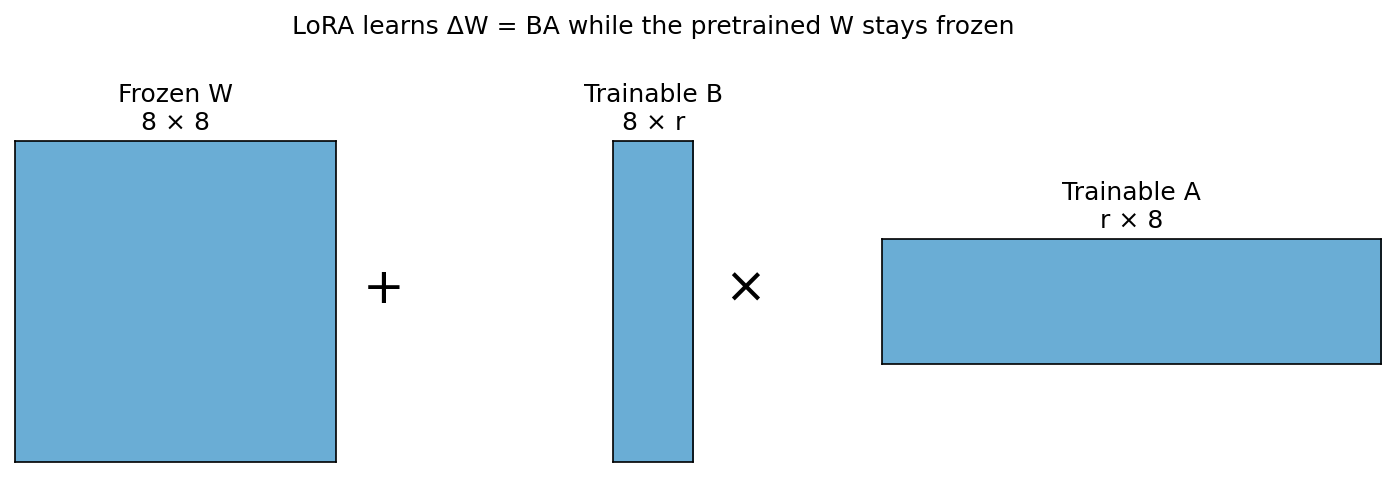

## Learn and test: Inspect one SFT example

SFT minimizes next-token loss on desired responses. Training on prompt tokens wastes capacity and can teach the model to imitate users, so labels before the assistant response are set to `-100`. LoRA learns low-rank updates while the base weights remain frozen.

### Work the smallest useful example

For a `4096×4096` weight, a dense update contains about 16.8 million values. Rank-16 factors contain `16×4096 + 4096×16 = 131,072`, under one percent of the dense count for that matrix. `alpha/r` scales the adapter path in standard LoRA. Target modules decide where capacity is inserted, dropout regularizes adapter inputs, and effective batch size is microbatch × accumulation × devices.

Keep this result visible. The code should reproduce the same relationship; if
it does not, locate the first value that differs before changing the model.

### Try it: Inspect one SFT example

**What this cell shows**

Trace one conversation from role-labeled messages to the exact tokens and labels used for training.

**What goes in and comes out**

- The example contains messages
- packaged rows additionally contain stable IDs and metadata.

**Follow the calculation**

1. Print one canonical record and verify roles before any tokenization or trainer construction.

**Before you run the cell**

Which message tokens should receive active labels? Write down the expected value, shape, or ordering before running the cell.

In [ ]:
from course_helpers import read_jsonl, split_prompt_completion

train_rows = read_jsonl(COURSE_ROOT / "data" / "classroom" / "sft_train.jsonl")
example = train_rows[0]
trainer_record = split_prompt_completion(example["messages"])
print("source:", example["source"], "tree:", example["source_tree_id"])
print("prompt roles:", [message["role"] for message in trainer_record["prompt"]])
print("completion role:", trainer_record["completion"][0]["role"])

**What you should see**

The assistant response is the learning target; earlier messages provide context.

**If your result looks different**

A messages column alone does not guarantee assistant-only loss; template support and configuration must be checked.

Before moving on, compare the output with your prediction. If they differ, use the data description and tensor shapes above to find the first unexpected step.

## Learn and test: Load prepared OpenAssistant rows

## Turning conversations into supervised loss

An SFT record is best stored as structured messages with stable source metadata. The tokenizer’s chat template renders those messages consistently. For response-only training, prompt and role-marker labels become `-100`, PyTorch cross-entropy’s ignore value, while assistant answer tokens keep their target IDs. This teaches the desired response without asking the model to predict the user prompt.

### Try it: Load prepared OpenAssistant rows

**What this cell shows**

Use the audited human-authored classroom snapshot rather than downloading unexpectedly in the middle of the workflow.

**What goes in and comes out**

- JSONL lines become a list of dictionaries
- the count is scalar and message-tree IDs are strings.

**Follow the calculation**

1. Read nonempty lines, parse JSON, inspect schema and count, and keep the manifest checksum nearby.

**Before you run the cell**

Predict the first row's required keys. Write down the expected value, shape, or ordering before running the cell.

In [ ]:
from datasets import Dataset

# A reduced run uses authentic rows; it changes the amount of data, not the source.
reduced_rows = [split_prompt_completion(row["messages"]) for row in train_rows[:32]]
train_dataset = Dataset.from_list(reduced_rows[:24])
validation_dataset = Dataset.from_list(reduced_rows[24:32])
print(train_dataset)
print("first prompt messages:", len(train_dataset[0]["prompt"]))

**What you should see**

The packaged snapshot preserves authentic OpenAssistant conversations while making reduced execution deterministic.

**If your result looks different**

Do not interpret a 2,000-conversation classroom subset as a full production training corpus.

Before moving on, compare the output with your prediction. If they differ, use the data description and tensor shapes above to find the first unexpected step.

## Learn and test: Configure the LoRA SFT run

Truncation policy matters. If truncation routinely removes the assistant answer, examples contribute little useful supervision. Packing several short conversations into one sequence improves utilization, but boundaries and loss masks must remain correct. Split by conversation tree before selecting branches so near-duplicate turns cannot leak into evaluation.

### Frozen layers still participate in prediction

Base modules remain in the forward and backward graphs even when only adapter parameters receive updates.

**Check your understanding:** Which tensors should report `requires_grad=True`, and why do frozen weights still affect every output?

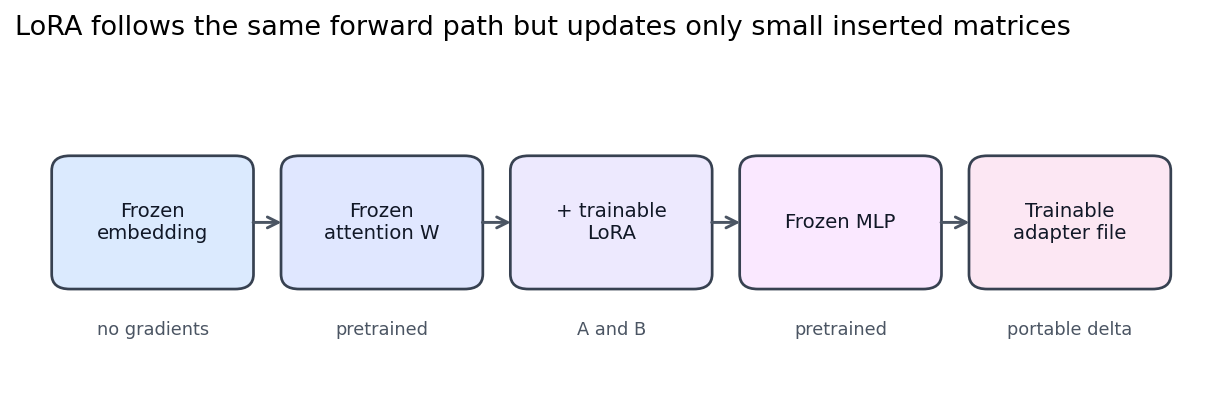

### Try it: Configure the LoRA SFT run

**What this cell shows**

Expose each model, adapter, and optimizer choice before launching CUDA work.

**What goes in and comes out**

- Token batches are `B×T`
- LoRA matrices match target projection dimensions
- loss is scalar.

**Follow the calculation**

1. Pin model revision, choose BF16, name Q/K/V/O projections, set rank/alpha/dropout, then configure microbatch, accumulation, rate, steps, logging, and checkpoints separately.

**Before you run the cell**

Which parameters should report `requires_grad=True` after PEFT injection? Write down the expected value, shape, or ordering before running the cell.

In [ ]:
import torch
from peft import LoraConfig
from transformers import AutoTokenizer
from trl import SFTConfig
from course_helpers import CLASSROOM_MODEL, CLASSROOM_REVISION

tokenizer = AutoTokenizer.from_pretrained(CLASSROOM_MODEL, revision=CLASSROOM_REVISION)
tokenizer.pad_token = tokenizer.pad_token or tokenizer.eos_token

lora_config = LoraConfig(
    r=8, lora_alpha=16, lora_dropout=0.05,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    task_type="CAUSAL_LM", bias="none",
)
output_dir = COURSE_ROOT / "adapters" / "student_run_lora"
training_args = SFTConfig(
    output_dir=str(output_dir), max_length=512, max_steps=2,
    per_device_train_batch_size=1, gradient_accumulation_steps=2,
    learning_rate=1e-4, logging_steps=1, save_strategy="no",
    report_to="none", seed=SEED, completion_only_loss=True,
    use_cpu=not torch.cuda.is_available(),
)
print(lora_config)
effective = (
    training_args.per_device_train_batch_size
    * training_args.gradient_accumulation_steps
)
print("effective batch:", effective)

**What you should see**

Only adapter parameters should be trainable unless modules are explicitly added; the base remains part of forward computation.

**If your result looks different**

A disabled flag is a reduced path, not a successful training result. Print the exact command and prerequisites.

Before moving on, compare the output with your prediction. If they differ, use the data description and tensor shapes above to find the first unexpected step.

## Learn and test: Calculate effective batch

LoRA freezes base weights and inserts trainable low-rank updates into selected projections. Attention projections are common targets. Rank controls adapter capacity; alpha scales the update; dropout regularizes it. A smaller learning rate is not automatically better—the adapter is randomly initialized and often uses a higher rate than full-model fine-tuning.

### Several microbatches can produce one optimizer update

Gradient accumulation delays the optimizer step while collecting scaled gradients from multiple microbatches.

**Check your understanding:** With microbatch 4 and accumulation 8, how many examples contribute to one single-device update?

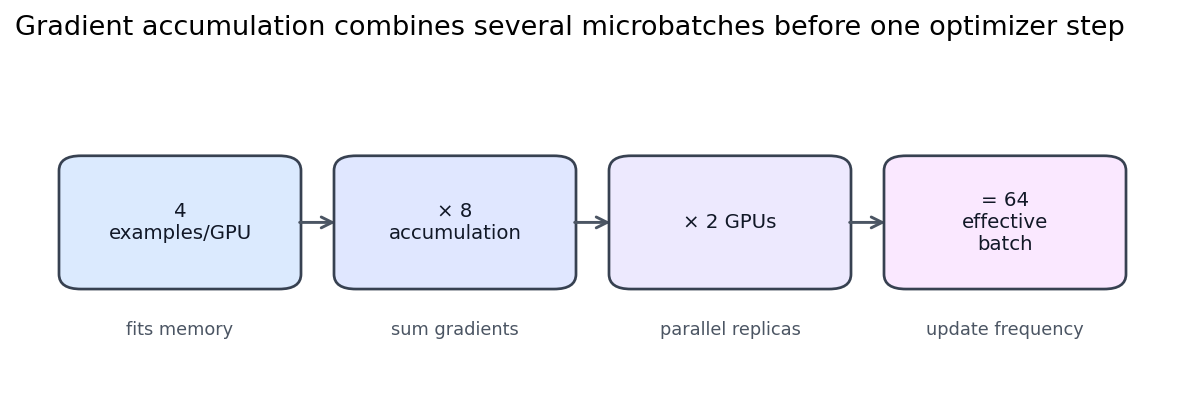

### Try it: Calculate effective batch

**What this cell shows**

Distinguish memory-fitting microbatches from optimizer update frequency.

**What goes in and comes out**

- Inputs are three integers
- output is examples per optimizer step.

**Follow the calculation**

1. Multiply per-device batch by accumulation steps and device count. Token counts may still vary with sequence length or packing.

**Before you run the cell**

What changes if accumulation doubles while the microbatch stays fixed? Write down the expected value, shape, or ordering before running the cell.

In [ ]:
from trl import SFTTrainer
from course_helpers import count_trainable_parameters

RUN_TRAINING = True
trainer = None
if RUN_TRAINING:
    trainer = SFTTrainer(
        model=CLASSROOM_MODEL,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=validation_dataset,
        processing_class=tokenizer,
        peft_config=lora_config,
    )
    print(count_trainable_parameters(trainer.model))
    result = trainer.train()
    trainer.save_model(output_dir)
    tokenizer.save_pretrained(output_dir)
    print("training loss:", result.training_loss)
    print("saved:", output_dir)

**What you should see**

The effective example batch doubles and optimizer steps occur half as often for the same examples.

**If your result looks different**

Effective examples are not necessarily effective tokens; report both when packing varies.

Before moving on, compare the output with your prediction. If they differ, use the data description and tensor shapes above to find the first unexpected step.

## Learn and test: Specify the QLoRA loading delta

Effective batch size equals per-device microbatch × accumulation steps × number of devices. Gradient accumulation saves activation memory but does not make each forward pass larger. Checkpoint evaluation should use fixed held-out prompts and the same decoding configuration as the base model.

### Fine-tuning methods trade memory for flexibility

Full tuning, LoRA, and QLoRA store and update different sets of tensors.

**Check your understanding:** Which comparison is about engineering cost rather than an automatic ranking of output quality?

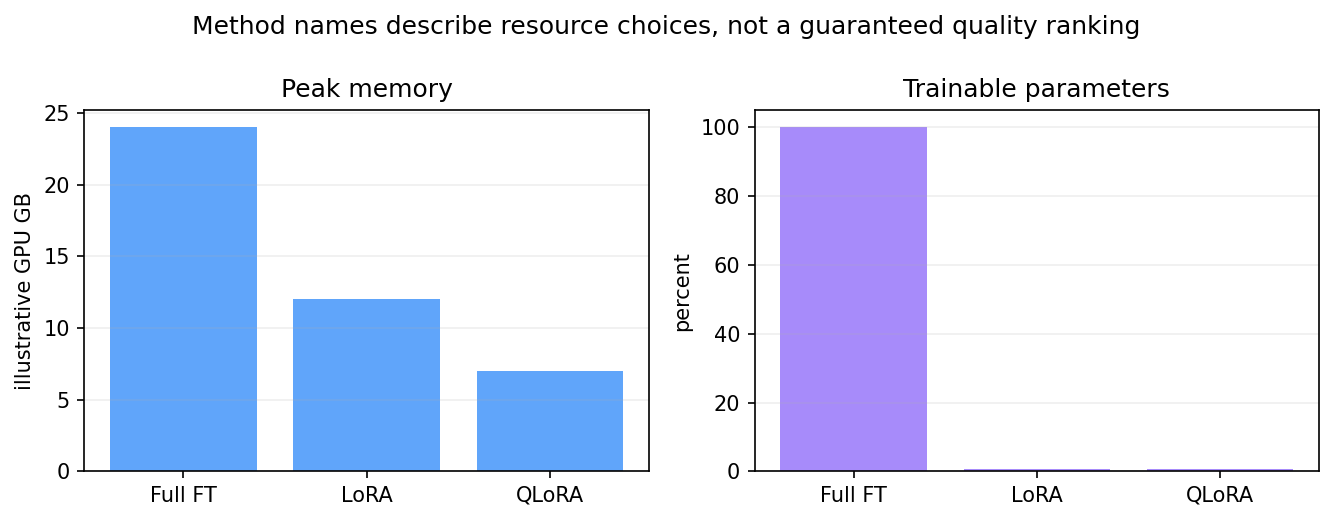

### Try it: Specify the QLoRA loading delta

**What this cell shows**

Show exactly what changes when the frozen base is stored in four-bit form.

**What goes in and comes out**

- The quantization configuration describes base-weight storage and BF16 compute
- LoRA rank and target modules remain separate.

**Follow the calculation**

1. Set four-bit loading, NF4 quantization, double quantization, and BF16 compute dtype. Keep the same SFT data objective and adapter configuration.

**Before you run the cell**

Which tensors remain trainable and at higher precision? Write down the expected value, shape, or ordering before running the cell.

In [ ]:
def effective_batch(per_device, accumulation, devices=1):
    return per_device * accumulation * devices

settings = [
    {"microbatch": 1, "accumulation": 2, "devices": 1},
    {"microbatch": 2, "accumulation": 4, "devices": 2},
]
for setting in settings:
    print(setting, "=>", effective_batch(
        setting["microbatch"], setting["accumulation"], setting["devices"]
    ), "examples per optimizer update")

**What you should see**

LoRA parameters remain trainable; the frozen base is quantized for storage, while important computation uses the selected compute dtype.

**If your result looks different**

Do not describe all four-bit fine-tuning as QLoRA unless the low-rank adapter and quantization recipe are both present.

Before moving on, compare the output with your prediction. If they differ, use the data description and tensor shapes above to find the first unexpected step.

## Learn and test: make the QLoRA difference executable

QLoRA keeps the LoRA matrices trainable but loads the frozen base weights in four-bit form. The quantization object must participate in model loading; printing a dictionary without passing it to `from_pretrained` does not create QLoRA. This extension requires Linux, CUDA, and `bitsandbytes`.

### Try it: construct and pass the quantization configuration

**Before running:** verify that `load_in_4bit=True`, NF4 is selected, and compute uses BF16. Expect the cell to skip honestly on unsupported hardware.

In [ ]:
RUN_QLORA = True
if RUN_QLORA:
    from transformers import AutoModelForCausalLM, BitsAndBytesConfig
    from peft import prepare_model_for_kbit_training
    from course_helpers import EXTENDED_MODEL, EXTENDED_REVISION

    quantization_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_use_double_quant=True,
        bnb_4bit_compute_dtype=torch.bfloat16,
    )
    qlora_model = AutoModelForCausalLM.from_pretrained(
        EXTENDED_MODEL, revision=EXTENDED_REVISION,
        quantization_config=quantization_config, device_map="auto",
    )
    qlora_model = prepare_model_for_kbit_training(qlora_model)
    qlora_trainer = SFTTrainer(
        model=qlora_model, args=training_args,
        train_dataset=train_dataset, processing_class=tokenizer,
        peft_config=lora_config,
    )
    print(count_trainable_parameters(qlora_trainer.model))
else:
    print("QLoRA skipped. Enable only on a Linux CUDA environment with bitsandbytes.")

In a real QLoRA run the loaded base layers report quantized storage while LoRA parameters remain floating point and trainable. If memory is unchanged, inspect the model's parameter dtypes and confirm the configuration was passed during loading—not created after the model already occupied memory.

## Learn and test: reload the saved adapter

Saving is not verification. We reconstruct the base at the pinned revision, attach the adapter from disk, and compare a fixed greedy answer. A missing `adapter_config.json` or base-model mismatch should fail here rather than during deployment.

### Try it: load a fresh PEFT model

**Before running:** check that the adapter directory contains configuration and Safetensors files. Predict which parameters will be trainable when `is_trainable=False`.

**Inputs and outputs:** The named Python objects enter this step; the printed values, token counts, tensor shapes, or saved files are the observations to check.

In [ ]:
if RUN_TRAINING:
    from peft import PeftModel
    from transformers import AutoModelForCausalLM
    from course_helpers import fixed_generate

    fresh_base = AutoModelForCausalLM.from_pretrained(
        CLASSROOM_MODEL, revision=CLASSROOM_REVISION,
        dtype=torch.float32 if not torch.cuda.is_available() else torch.bfloat16,
    )
    reloaded = PeftModel.from_pretrained(fresh_base, output_dir, is_trainable=False).eval()
    test_messages = [{"role": "user", "content": "Explain why validation data is kept separate."}]
    print(fixed_generate(reloaded, tokenizer, test_messages, max_new_tokens=60))
    print(count_trainable_parameters(reloaded))

The reloaded adapter should generate without any trainable parameters. Two training steps are only a systems check, not evidence of improved quality. Lecture 04 separates “the artifact reloads” from “the artifact improves held-out behavior.”

## A realistic failure—and what it teaches us

QLoRA does not train four-bit adapter values. It stores the frozen base quantized while LoRA parameters and important computation remain at higher precision. Targeting nonexistent module names, forgetting to print trainable parameters, using an incompatible assistant-only template, or treating `device_map='auto'` as a training strategy are common failures. The reduced path will validate configuration without pretending that disabled training produced an adapter.

**Debugging habit:** find the first expectation that failed—data
identity, shape, normalization, causality, optimization, retrieval,
grounding, or authorization. Then write the smallest check that
separates that problem from the nearby possibilities.

## Practice checkpoint

Construct a toy token/label sequence where only the assistant answer contributes to loss. Assert all prompt labels equal `-100`.

Before editing code, write a prediction and name the invariant that should remain true. Record the observed result in this notebook, compare it with your prediction, and write one sentence explaining any discrepancy.

## Instructor check-in

After running the practice checkpoint, send a short email from your Clemson account. Include your full name, Clemson email, observed evidence, and interpretation.

**Evidence to include:** Report the effective batch size and trainable-parameter percentage from your run, then state whether the saved adapter reloaded successfully.

The final line is not only for problems. You may send a question **or** describe something that worked well or changed your understanding.

[📧 Send the checkpoint email](mailto:fanchem@clemson.edu?subject=Watt%20AI%20lesson%20check-in%20-%20Lesson%2003%20-%20Supervised%20fine-tuning&body=Lesson%2003%20-%20Supervised%20fine-tuning%0A%0AFull%20name%3A%0AClemson%20email%3A%0A%0AObserved%20evidence%3A%0A%0AWhat%20the%20evidence%20means%3A%0A%0AOne%20remaining%20question%20or%20one%20useful%20takeaway%3A)

If the button does not open your Clemson mail client, email [fanchem@clemson.edu](mailto:fanchem@clemson.edu) with the subject **Watt AI lesson check-in — Lesson 03 - Supervised fine-tuning** and use the same fields above.

## Check your work

Expand the reference solution only after attempting the exercise.

In [ ]:
prompt_ids, answer_ids = [10, 11, 12, 13], [20, 21, 22]
input_ids = prompt_ids + answer_ids
labels = [-100] * len(prompt_ids) + answer_ids
assert all(label == -100 for label in labels[:len(prompt_ids)])
print(input_ids, labels)

## Final concept map

Dense update problem → low-rank factorization → PEFT injection into named projections → trainable-parameter audit → SFT configuration → assistant-only batch → accumulated updates → adapter checkpoint; QLoRA changes frozen-base storage and loading, not the dataset objective.

Return to the driving question: **How can a small trainable update change a large frozen model, and what does QLoRA change further?** Explain the answer without using library names. Then identify which new limitation motivates the next lecture.

## Homework

Fine-tune with one controlled hyperparameter change. Compare fixed-prompt outputs, validation loss, GPU memory, and adapter size.

The full assignment and rubric are in this course's `homework/` folder.
Attempt the work before opening the collapsed check-your-work cell above.

## Glossary

| Term | Meaning in this lesson |
|---|---|
| **LoRA** | A low-rank trainable update attached to a frozen weight. |
| **rank** | The inner dimension controlling adapter capacity and size. |
| **alpha** | A scaling hyperparameter for the adapter contribution. |
| **target module** | A named layer receiving adapters. |
| **QLoRA** | LoRA training over a quantized frozen base. |
| **gradient accumulation** | Combining microbatch gradients before one optimizer update. |

A useful definition lets you predict behavior. Test yourself by giving one example and one non-example for every term rather than memorizing the wording.

## Sources and further study

The explanations, code, numeric examples, and figures in this notebook are course-original. These primary or official sources check terminology and provide a deeper path:

- [PEFT LoRA Guide](https://huggingface.co/docs/peft/main/conceptual_guides/lora) — Official adapter concepts and configuration meanings.
- [TRL SFTTrainer](https://huggingface.co/docs/trl/sft_trainer) — Official SFT data, masking, packing, and trainer behavior.
- [QLoRA](https://arxiv.org/abs/2305.14314) — Primary source for NF4, double quantization, and paged optimizers.

- [Clemson CITI fine-tuning workshop](https://clemsonciti.github.io/rcde_workshops/llms_finetune/00-index.html) and [alternatives to fine-tuning](https://clemsonciti.github.io/rcde_workshops/llms_finetune/01-alternatives.html) — optional structural comparison and further reading; no workshop prose or images are copied.

- [SmolLM2-135M-Instruct model card](https://huggingface.co/HuggingFaceTB/SmolLM2-135M-Instruct) — pinned classroom artifact and license.
- [Bitsandbytes quantization](https://huggingface.co/docs/transformers/quantization/bitsandbytes) — official four-bit loading behavior.

Source role: conceptual or implementation verification. Accessed 2026-08-18. External images are not hotlinked; redistributed assets require the course license manifest.